# Features Generation Cost Estimation

In [8]:
import os
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

In [9]:
script_path = os.getcwd()
project_path = os.path.join(script_path, '..')
generation_cost_dir = os.path.join(project_path, 'data', 'generation_cost')
total_cost_file_path = os.path.join(generation_cost_dir, 'total_cost.csv')

In [10]:
total_cost_df = pl.read_csv(total_cost_file_path)
total_cost_df

llm_model_name,embedding_model_name,n1,fil_prop,n2,total_cost
str,str,i64,f64,f64,f64
"""gpt-4o-mini""","""text-embedding-3-small""",10000,0.9,9000.0,6.219
"""gpt-4o""","""text-embedding-3-small""",10000,0.9,9000.0,103.35
"""gpt-4o-mini""","""text-embedding-3-small""",10000,0.8,8000.0,5.628
"""gpt-4o""","""text-embedding-3-small""",10000,0.8,8000.0,93.53
"""gpt-4o-mini""","""text-embedding-3-small""",10000,0.7,7000.0,5.037
…,…,…,…,…,…
"""gpt-4o""","""text-embedding-3-small""",70000,0.8,56000.0,654.71
"""gpt-4o-mini""","""text-embedding-3-small""",70000,0.7,49000.0,35.259
"""gpt-4o""","""text-embedding-3-small""",70000,0.7,49000.0,585.97


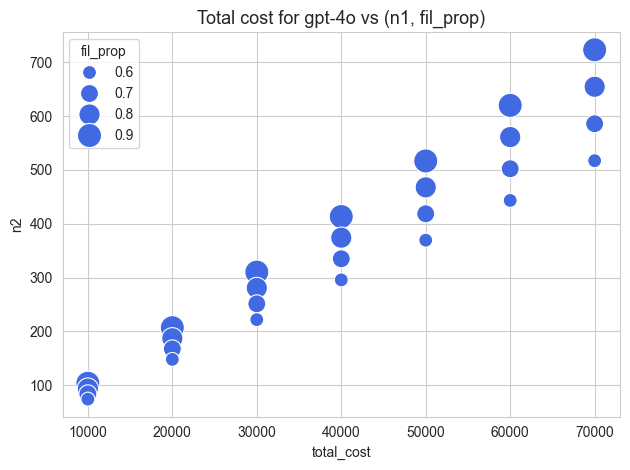

In [11]:
llm_model_name = "gpt-4o"

sns.scatterplot(
    data=total_cost_df.filter(pl.col('llm_model_name') == llm_model_name),
    x="n1",
    y="total_cost",
    size="fil_prop",
    sizes=(100, 300), 
    color='royalblue'
)

plt.xlabel("total_cost")
plt.ylabel("n2")
plt.title(f"Total cost for {llm_model_name} vs (n1, fil_prop)", fontsize=13)

plt.tight_layout()
plt.show()


LLM model: gpt-4o

- Least costly scenario: 50$ (n1=10000, fil_prop=0.6)
- Middle costly scenario: 310$ (n1=30000, fil_prop=0.9)
- Most costly scenario: 720$ (n1=70000, fil_prop=0.9)
- Realistic scenario (n1=30000-40000, fil_prop=0.6-0.8): 210$-380$

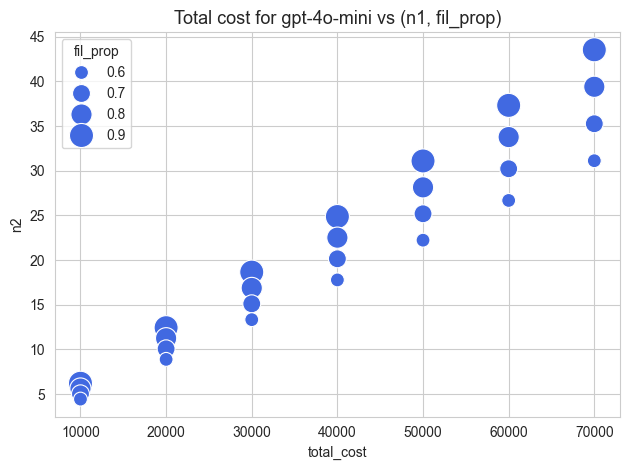

In [12]:
llm_model_name = "gpt-4o-mini"

sns.scatterplot(
    data=total_cost_df.filter(pl.col('llm_model_name') == llm_model_name),
    x="n1",
    y="total_cost",
    size="fil_prop",
    sizes=(100, 300), 
    color='royalblue'
)

plt.xlabel("total_cost")
plt.ylabel("n2")
plt.title(f"Total cost for {llm_model_name} vs (n1, fil_prop)", fontsize=13)

plt.tight_layout()
plt.show()


LLM model: gpt-4o-mini

- Least costly scenario: 4$ (n1=10000, fil_prop=0.6)
- Middle costly scenario: 18$ (n1=30000, fil_prop=0.9)
- Most costly scenario: 44$ (n1=70000, fil_prop=0.9)
- Realistic scenario (n1=30000-40000, fil_prop=0.6-0.8): 13$-23$

**Conclusion:** 

- gpt-4o-mini is a very affordable option, since cost will not exceed 50$ even in big data scenarios. 